In [2]:
import pandas as pd

In [4]:
df = pd.read_csv("Advertising.csv")

In [8]:
df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


### Data Cleaning

In [13]:
df.drop('Unnamed: 0', axis=1, inplace=True)

In [15]:
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [20]:
df.isnull().sum()

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

In [24]:
df.duplicated().sum()

0

In [30]:
(df[['TV', 'Radio', 'Newspaper', 'Sales']] < 0).sum()

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

<div style="font-family: Calibri;">

##### Data Cleaning: The dataset was inspected for missing values, duplicate records, incorrect data types, and invalid negative values. No missing or duplicate records were found, and all relevant variables were numerical and valid. The unnecessary Unnamed: 0 index column was removed before further analysis.

</div>

## EDA

In [42]:
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


In [44]:
df.median()

TV           149.75
Radio         22.90
Newspaper     25.75
Sales         12.90
dtype: float64

In [46]:
df.corr()

,TV,Radio,Newspaper,Sales
TV,1.000000,0.054809,0.056648,0.782224
Radio,0.054809,1.000000,0.354104,0.576223
Newspaper,0.056648,0.354104,1.000000,0.228299
Sales,0.782224,0.576223,0.228299,1.000000


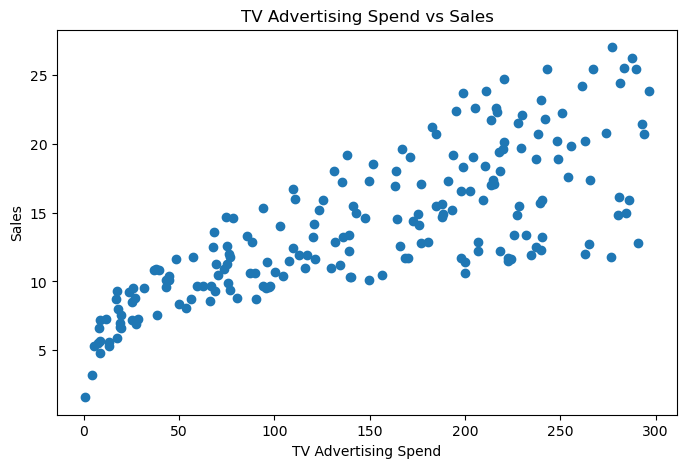

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.scatter(df['TV'], df['Sales'])
plt.xlabel('TV Advertising Spend')
plt.ylabel('Sales')
plt.title('TV Advertising Spend vs Sales')
plt.show()

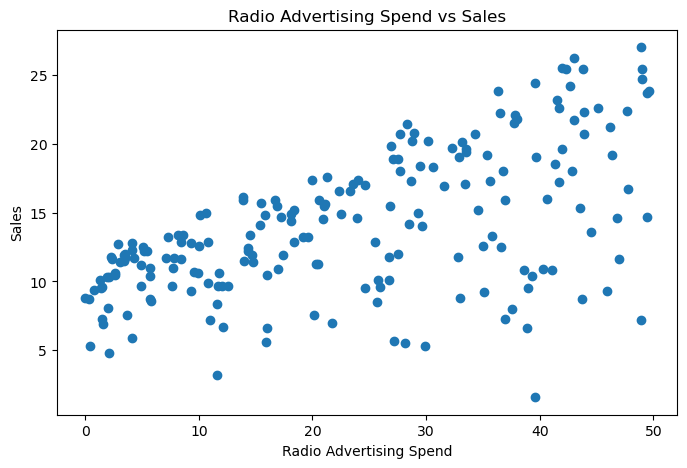

In [64]:
plt.figure(figsize=(8, 5))
plt.scatter(df['Radio'], df['Sales'])
plt.xlabel('Radio Advertising Spend')
plt.ylabel('Sales')
plt.title('Radio Advertising Spend vs Sales')
plt.show()

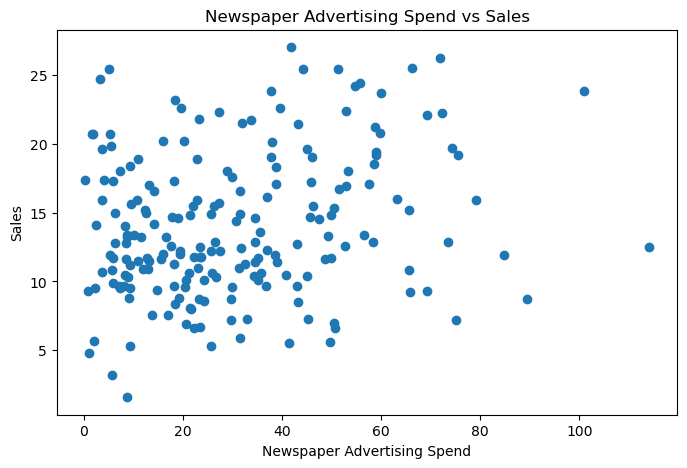

In [70]:
plt.figure(figsize=(8, 5))
plt.scatter(df['Newspaper'], df['Sales'])
plt.xlabel('Newspaper Advertising Spend')
plt.ylabel('Sales')
plt.title('Newspaper Advertising Spend vs Sales')
plt.show()

<div style="font-family: calibri;">

#### Observation: The scatter plot shows a weak positive relationship between Newspaper advertising expenditure and Sales. The data points are widely dispersed, indicating that Newspaper advertising alone does not strongly explain variations in Sales. This is consistent with the correlation coefficient of 0.228.
    
</div>

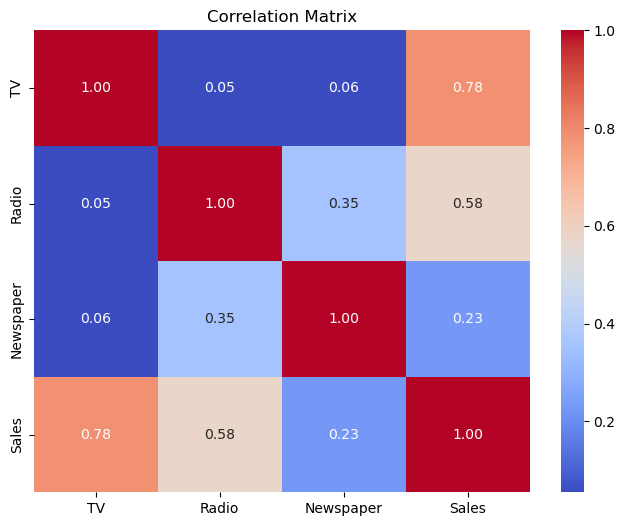

In [74]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix')
plt.show()

<div style = "font-family: calibri;">

#### Observation: The correlation matrix shows that TV advertising has the strongest positive relationship with Sales (0.78), followed by Radio (0.58), while Newspaper has a relatively weak positive relationship (0.23). The advertising channels also show relatively low correlation with one another, suggesting limited multicollinearity among the predictors.
    
</div>

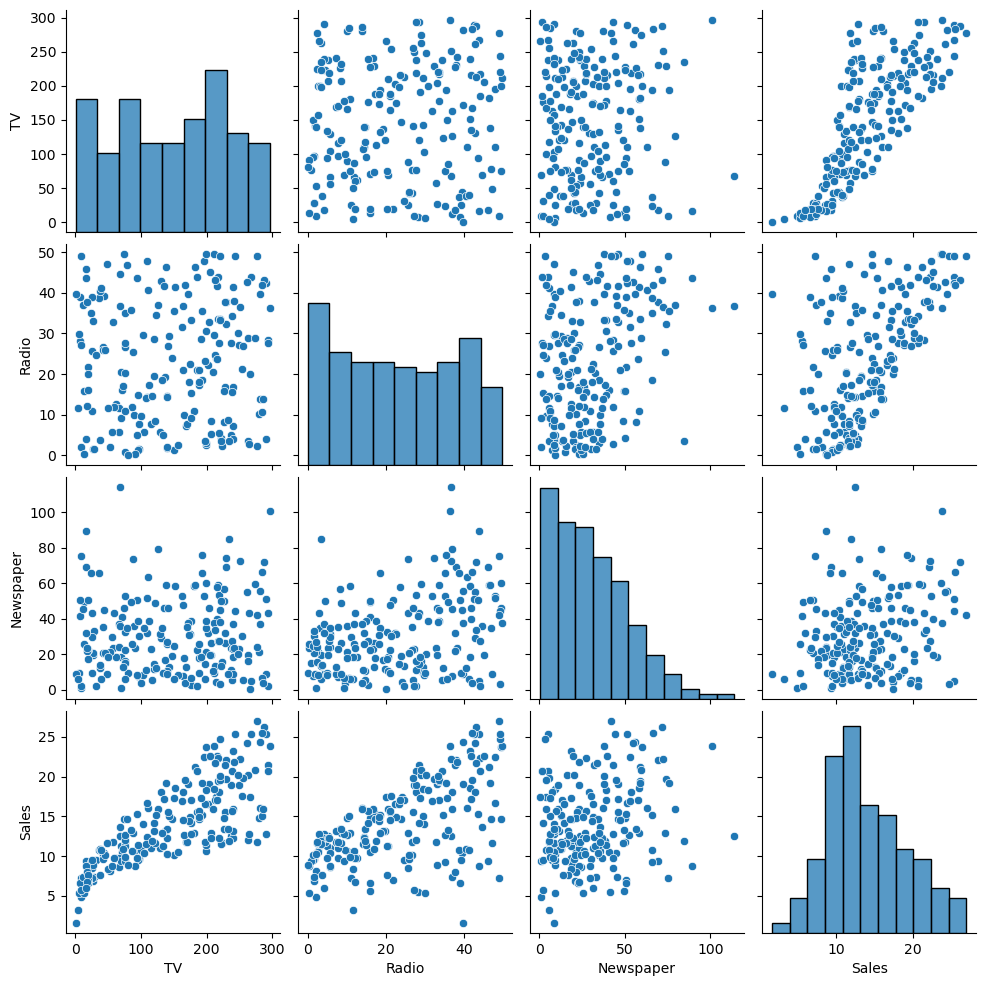

In [79]:
sns.pairplot(
    df,
    diag_kind='hist'
)

plt.show()

In [85]:
Q1 = df[['TV', 'Radio', 'Newspaper', 'Sales']].quantile(0.25)
Q3 = df[['TV', 'Radio', 'Newspaper', 'Sales']].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = (
    (df[['TV', 'Radio', 'Newspaper', 'Sales']] < lower_bound) |
    (df[['TV', 'Radio', 'Newspaper', 'Sales']] > upper_bound)
)

outliers.sum()

TV           0
Radio        0
Newspaper    2
Sales        0
dtype: int64

## Feature Selection

In [91]:
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

In [93]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [95]:
X_train.shape

(160, 3)

In [99]:
X_test.shape

(40, 3)

# 1. LinearRegression

In [102]:
from sklearn.linear_model import LinearRegression

# Create the model
lr_model = LinearRegression()

# Train the model
lr_model.fit(X_train, y_train)

LinearRegression()

In [104]:
y_pred = lr_model.predict(X_test)

In [106]:
y_pred[:10]

array([16.4080242 , 20.88988209, 21.55384318, 10.60850256, 22.11237326,
       13.10559172, 21.05719192,  7.46101034, 13.60634581, 15.15506967])

In [108]:
y_test[:10].values

array([16.9, 22.4, 21.4,  7.3, 24.7, 12.6, 22.3,  8.4, 11.5, 14.9])

## Model Evaluation

In [110]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 1.4607567168117606
RMSE: 1.7815996615334502
R² Score: 0.899438024100912


In [113]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_model.coef_
})

coefficients

,Feature,Coefficient
0,TV,0.044730
1,Radio,0.189195
2,Newspaper,0.002761


In [115]:
print("Intercept:", lr_model.intercept_)

Intercept: 2.979067338122629


<div style= "font-family: calibri;">

### The regression coefficients indicate positive relationships between all three advertising channels and Sales. Radio has the largest coefficient (0.189), followed by TV (0.045), while Newspaper has a relatively small coefficient (0.003). These coefficients represent the estimated change in Sales for a one-unit increase in each advertising channel while keeping the other variables constant.
    
</div>

# 2. RandomForestRegressor

In [123]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

In [125]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest MAE:", rf_mae)
print("Random Forest RMSE:", rf_rmse)
print("Random Forest R² Score:", rf_r2)

Random Forest MAE: 0.6200999999999988
Random Forest RMSE: 0.7685910811348248
Random Forest R² Score: 0.9812843792541843


In [127]:
model_comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE': [mae, rf_mae],
    'RMSE': [rmse, rf_rmse],
    'R² Score': [r2, rf_r2]
})

model_comparison

,Model,MAE,RMSE,R² Score
0,Linear Regression,1.460757,1.781600,0.899438
1,Random Forest,0.620100,0.768591,0.981284


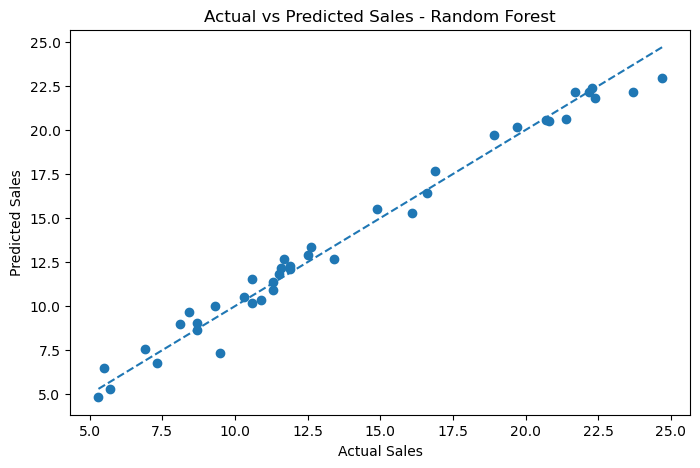

In [131]:
plt.figure(figsize=(8, 5))

plt.scatter(y_test, rf_pred)

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--'
)

plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Actual vs Predicted Sales - Random Forest')
plt.show()

## Sales Prediction

In [136]:
df['Predicted_Sales'] = rf_model.predict(X)

df.head()

,TV,Radio,Newspaper,Sales,Predicted_Sales
0,230.1,37.8,69.2,22.1,21.988
1,44.5,39.3,45.1,10.4,10.721
2,17.2,45.9,69.3,9.3,8.714
3,151.5,41.3,58.5,18.5,18.506
4,180.8,10.8,58.4,12.9,13.388


In [140]:
# Prediction Error

df['Prediction_Error'] = df['Sales'] - df['Predicted_Sales']

df.head()

,TV,Radio,Newspaper,Sales,Predicted_Sales,Prediction_Error
0,230.1,37.8,69.2,22.1,21.988,0.112
1,44.5,39.3,45.1,10.4,10.721,-0.321
2,17.2,45.9,69.3,9.3,8.714,0.586
3,151.5,41.3,58.5,18.5,18.506,-0.006
4,180.8,10.8,58.4,12.9,13.388,-0.488


## Advertising Impact Analysis

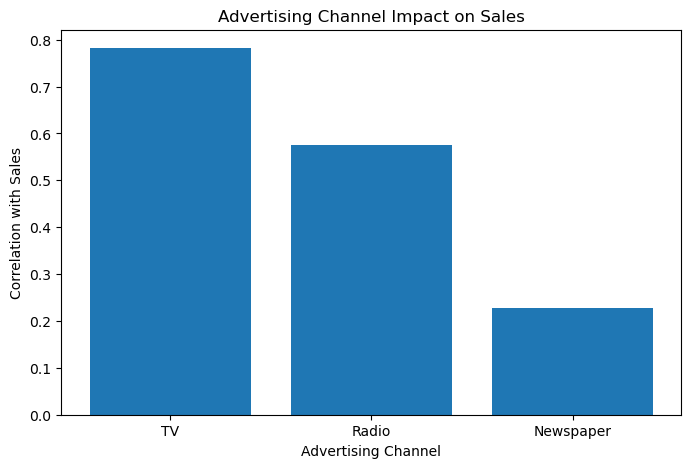

In [143]:
advertising_corr = df[['TV', 'Radio', 'Newspaper', 'Sales']].corr()['Sales'].drop('Sales')

plt.figure(figsize=(8, 5))

plt.bar(advertising_corr.index, advertising_corr.values)

plt.xlabel('Advertising Channel')
plt.ylabel('Correlation with Sales')
plt.title('Advertising Channel Impact on Sales')

plt.show()

<div style="font-family: calibri;">

TV advertising shows the strongest positive relationship with Sales, followed by Radio. Newspaper advertising has a comparatively weak relationship with Sales. Therefore, TV and Radio appear to be more influential channels for sales performance in this dataset.
    
</div>

## Actionable Marketing Insights

<div style="font_family: calibri;">

The analysis shows that different advertising channels have varying relationships with Sales. TV advertising has the strongest positive correlation with Sales, followed by Radio, while Newspaper advertising has a relatively weak relationship.

The Random Forest model achieved an R² score of 0.981, indicating strong predictive performance. Based on the analysis, marketing resources should prioritize channels that demonstrate stronger relationships with sales while continuously evaluating campaign performance.

Key recommendations:
- Prioritize TV advertising when the objective is to maximize sales based on the observed historical relationship.
- Consider Radio advertising as another effective channel for supporting sales growth.
- Evaluate Newspaper advertising carefully and avoid increasing spending solely based on historical sales relationships.
- Use the predictive model to estimate expected sales for different advertising budgets before making allocation decisions.
- Continuously monitor actual sales against predicted sales to improve future marketing decisions.
    
</div>

## Conclusion



This project analyzed the relationship between advertising expenditure and Sales using the TV, Radio, and Newspaper advertising channels.

After data cleaning and exploratory analysis, Linear Regression and Random Forest Regression were developed and evaluated. Random Forest performed better, achieving an MAE of 0.62, RMSE of 0.77, and R² score of 0.981 on the test set.

The analysis showed that TV had the strongest correlation with Sales, followed by Radio, while Newspaper showed a weaker relationship. The trained Random Forest model can also be used to estimate expected sales for a given advertising budget.

Overall, the analysis demonstrates how machine learning can support sales forecasting and help businesses make more informed advertising and marketing decisions.